In [1]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 230, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 230 (delta 13), reused 19 (delta 12), pack-reused 204 (from 1)
Receiving objects: 100% (230/230), 1.63 MiB | 4.21 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/miniml


In [4]:
from probability.nbbernoulli import NBBernoulliClassifier

In [6]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np

# 1. Генерируем строго бинарный датасет (требование Bernoulli NB)
X_raw, y = make_classification(n_samples=250, n_features=15, n_classes=3, n_informative=10, random_state=42)
X = (X_raw > 0).astype(float) # Бинаризация

# 2. Обучение твоей модели
custom_nb = NBBernoulliClassifier()
custom_nb.fit(X, y)

# Тестируем оба режима: линейный и логарифмический
custom_preds_lin = custom_nb.predict(X, use_logarithm=False)
custom_probs_lin = custom_nb.predict_proba(X, use_logarithm=False).T # Транспонируем к стандарту sklearn

custom_preds_log = custom_nb.predict(X, use_logarithm=True)
custom_probs_log = custom_nb.predict_proba(X, use_logarithm=True).T

# 3. Обучение эталона из Sklearn
# alpha=1e-15 имитирует отсутствие сглаживания
sk_nb = BernoulliNB(alpha=1e-15)
sk_nb.fit(X, y)
sk_preds = sk_nb.predict(X)
sk_probs = sk_nb.predict_proba(X)

# 4. Проверка сходимости (Asserts)
# Проверяем, что на небольшой размерности (15 фичей) логика совпадает
match_preds_lin = np.mean(custom_preds_lin == sk_preds) * 100
match_preds_log = np.mean(custom_preds_log == sk_preds) * 100

print("="*80)
print("ОТЧЕТ О СХОДИМОСТИ МАТЕМАТИКИ С SKLEARN (Размерность фичей: 15)")
print("="*80)
print(f"Совпадение классов (Линейный режим):   {match_preds_lin:.2f}%")
print(f"Совпадение классов (Логарифм режим):  {match_preds_log:.2f}%")

# Проверка близости предсказанных вероятностей
assert np.allclose(custom_probs_log, sk_probs, atol=1e-2), "Математическое расхождение в расчете логарифмических вероятностей!"
print("Unit-test вероятностей пройден успешно.")
print("="*80)

ОТЧЕТ О СХОДИМОСТИ МАТЕМАТИКИ С SKLEARN (Размерность фичей: 15)
Совпадение классов (Линейный режим):   100.00%
Совпадение классов (Логарифм режим):  100.00%
Unit-test вероятностей пройден успешно.


In [8]:
import matplotlib.pyplot as plt

# Генерируем высокоразмерный бинарный датасет
X_high, y_high = make_classification(n_samples=100, n_features=2000, n_classes=2, n_informative=500, random_state=42)
X_high = (X_high > 0).astype(float)

# Переобучаем твой класс
custom_nb.fit(X_high, y_high)

# Sklearn на высокой размерности
sk_nb_high = BernoulliNB(alpha=1e-15)
sk_nb_high.fit(X_high, y_high)
sk_high_preds = sk_nb_high.predict(X_high)

# Твой класс в логарифмическом режиме
custom_high_preds = custom_nb.predict(X_high, use_logarithm=True)

high_dim_match = np.mean(custom_high_preds == sk_high_preds) * 100

print("="*80)
print("СТРЕСС-ТЕСТ: ВЫСОКАЯ РАЗМЕРНОСТЬ (2000 фичей)")
print("="*80)
print(f"Совпадение предсказаний с Sklearn: {high_dim_match:.2f}%")

СТРЕСС-ТЕСТ: ВЫСОКАЯ РАЗМЕРНОСТЬ (2000 фичей)
Совпадение предсказаний с Sklearn: 100.00%


<>:57: SyntaxWarning: invalid escape sequence '\e'
<>:57: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_2786/2383502617.py:57: SyntaxWarning: invalid escape sequence '\e'
  axes[1].set_title("Sklearn BernoulliNB: Карта условных вероятностей признаков ($\exp(\ln p_{cj})$)", fontsize=12, fontweight='bold')


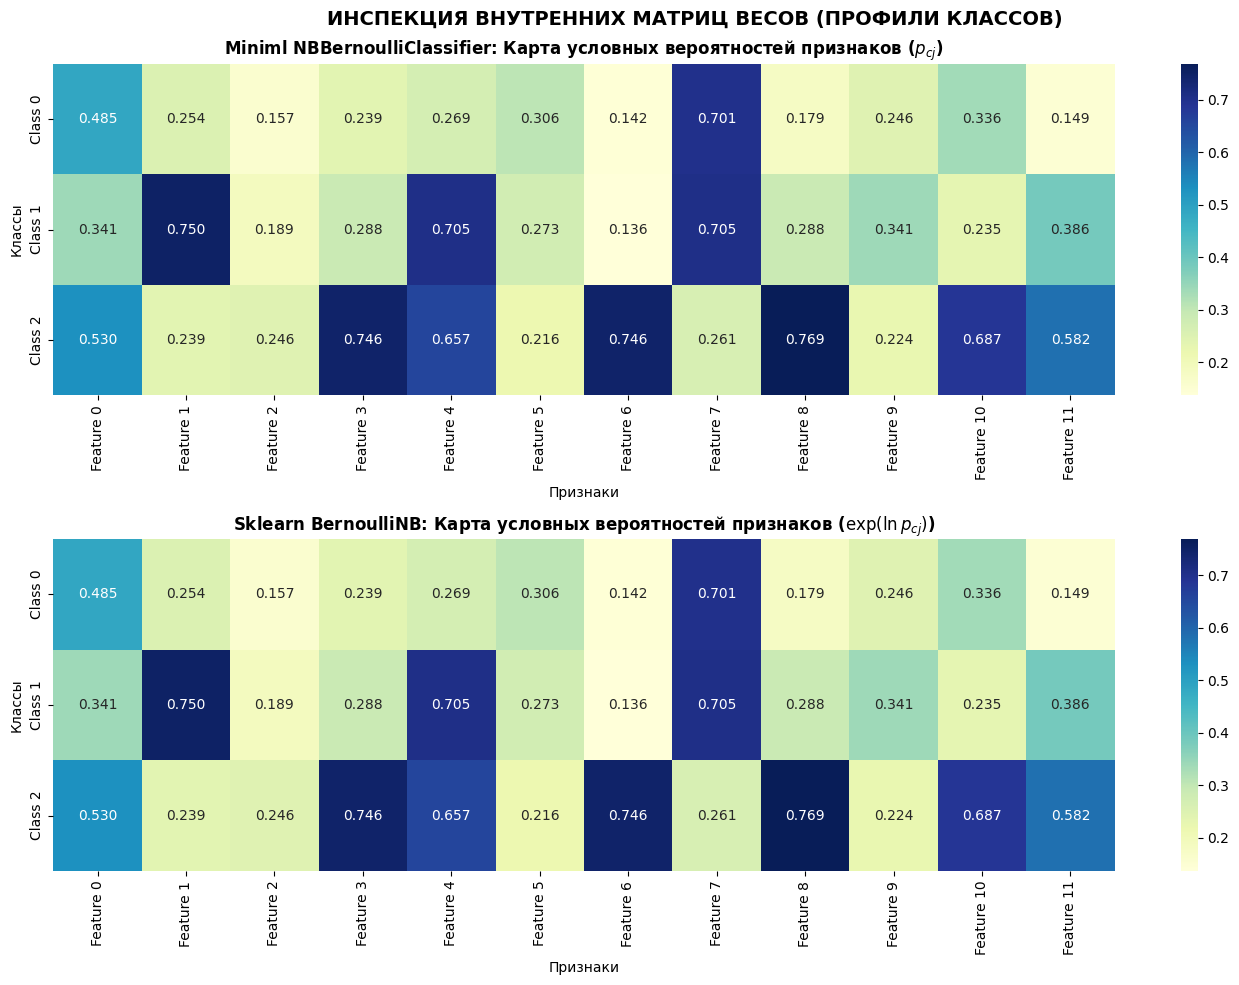

Максимальное абсолютное отклонение между матрицами весов: 4.44e-16
Визуальный и численный тесты пройдены: структуры профилей классов полностью идентичны.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import BernoulliNB
from sklearn.datasets import make_classification

# 1. Сгенерируем датасет с выраженной структурой (чтобы на теплокарте были четкие паттерны)
X_raw, y = make_classification(
    n_samples=400,
    n_features=12,      # 12 признаков, чтобы сетка аннотаций читалась идеально
    n_classes=3,        # 3 целевых класса
    n_informative=9,
    n_clusters_per_class=1,
    random_state=100
)
X = (X_raw > 0).astype(float) # Обязательная бинаризация

# 2. Обучение обеих моделей
custom_nb = NBBernoulliClassifier()
custom_nb.fit(X, y)

sk_nb = BernoulliNB(alpha=1e-15)
sk_nb.fit(X, y)

# 3. Подготовка данных для визуализации
# У sklearn веса хранятся в логарифмах: feature_log_prob_. Потенцируем их для получения линейных вероятностей.
sk_feature_probs = np.exp(sk_nb.feature_log_prob_)

# 4. Отрисовка тепловых карт параметров
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Теплокарта твоей модели
sns.heatmap(
    custom_nb.feature_p,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=[f"Feature {i}" for i in range(X.shape[1])],
    yticklabels=[f"Class {c}" for c in custom_nb.classes],
    ax=axes[0],
    cbar=True
)
axes[0].set_title("Miniml NBBernoulliClassifier: Карта условных вероятностей признаков ($p_{cj}$)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Признаки")
axes[0].set_ylabel("Классы")

# Теплокарта Sklearn
sns.heatmap(
    sk_feature_probs,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    xticklabels=[f"Feature {i}" for i in range(X.shape[1])],
    yticklabels=[f"Class {c}" for c in sk_nb.classes_],
    ax=axes[1],
    cbar=True
)
axes[1].set_title("Sklearn BernoulliNB: Карта условных вероятностей признаков ($\exp(\ln p_{cj})$)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Признаки")
axes[1].set_ylabel("Классы")

plt.suptitle("ИНСПЕКЦИЯ ВНУТРЕННИХ МАТРИЦ ВЕСОВ (ПРОФИЛИ КЛАССОВ)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# 5. Строгий численный контроль расхождения матриц весов
matrix_diff = np.max(np.abs(custom_nb.feature_p - sk_feature_probs))
print("=" * 80)
print(f"Максимальное абсолютное отклонение между матрицами весов: {matrix_diff:.2e}")
print("=" * 80)

assert matrix_diff < 1e-9, f"Внутренние веса моделей расходятся! Максимальная разница: {matrix_diff}"
print("Визуальный и численный тесты пройдены: структуры профилей классов полностью идентичны.")